# Notebook 05 — PPO training and validation research workflow

This notebook demonstrates the production single-symbol **TRAIN → VALIDATION** workflow for Milestone 5B-4. It trains one in-memory PPO model, evaluates it against deterministic baselines on VALIDATION, and exercises persistence only inside a temporary directory.

> **Research boundary:** TEST remains sealed. This notebook does not train the full universe, tune hyperparameters, save to production locations, register a production model, or promote a candidate.

In [1]:
from pathlib import Path
import json
import platform
import sys
import tempfile

PROJECT_ROOT = Path.cwd().resolve()
if PROJECT_ROOT.name == 'notebooks':
    PROJECT_ROOT = PROJECT_ROOT.parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import gymnasium
import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import stable_baselines3
import torch
from IPython.display import Markdown, display

expected_python = (PROJECT_ROOT / '.venv' / 'bin' / 'python').resolve()
actual_python = Path(sys.executable).resolve()
venv_ok = actual_python == expected_python and Path(sys.prefix).resolve() == (PROJECT_ROOT / '.venv').resolve()
assert venv_ok, f'Notebook kernel is not the project .venv: {sys.executable}'

environment_report = pd.DataFrame({
    'Value': [
        str(PROJECT_ROOT), sys.executable, platform.python_version(),
        stable_baselines3.__version__, torch.__version__, gymnasium.__version__,
        matplotlib.__version__, bool(torch.backends.mps.is_built()),
        bool(torch.backends.mps.is_available()), venv_ok,
    ]
}, index=[
    'Project Root', 'Python Executable', 'Python Version',
    'Stable-Baselines3', 'PyTorch', 'Gymnasium', 'Matplotlib',
    'MPS Built', 'MPS Available', 'Project .venv Verified',
])
display(environment_report)

Matplotlib is building the font cache; this may take a moment.


,Value
Project Root,/Users/m.abdulbasit/Downloads/virtual-trader
Python Executable,/Users/m.abdulbasit/Downloads/virtual-trader/....
Python Version,3.11.9
Stable-Baselines3,2.9.0
PyTorch,2.13.0
Gymnasium,1.3.0
Matplotlib,3.11.1
MPS Built,True
MPS Available,True
Project .venv Verified,True


## Reproducible staged experiment

The current MLP PPO benchmark found CPU approximately 6.81× faster than Apple MPS, so this notebook explicitly retains CPU. The demonstration uses a moderate rollout-aligned run. The 100,000-step production default is shown for context only and is **not** an accidental Run All setting.

In [2]:
from reinforcement_learning.training import PPOConfig, resolve_torch_device

SYMBOL = 'MCB'
SEED = 42
RANDOM_BASELINE_SEED = 42
DEVICE = 'cpu'
SMOKE_TIMESTEPS = 512
RESEARCH_DEMO_TIMESTEPS = 10_240
PRODUCTION_DEFAULT_TIMESTEPS = PPOConfig().total_timesteps
TIMESTEPS = RESEARCH_DEMO_TIMESTEPS

ppo_config = PPOConfig(seed=SEED, total_timesteps=TIMESTEPS, device=DEVICE)
device_resolution = resolve_torch_device(ppo_config.device)
assert ppo_config.device == 'cpu' and device_resolution.resolved_device == 'cpu'

experiment_configuration = pd.Series({
    'Symbol': SYMBOL,
    'Seed': SEED,
    'Configured Device': ppo_config.device,
    'Resolved Device': device_resolution.resolved_device,
    'Smoke Timesteps': SMOKE_TIMESTEPS,
    'Notebook Demonstration Timesteps': TIMESTEPS,
    'Production Default / Future Pilot Timesteps': PRODUCTION_DEFAULT_TIMESTEPS,
}, name='Experiment Configuration')
display(experiment_configuration.to_frame())

,Experiment Configuration
Symbol,MCB
Seed,42
Configured Device,cpu
Resolved Device,cpu
Smoke Timesteps,512
Notebook Demonstration Timesteps,10240
Production Default / Future Pilot Timesteps,100000


## Safety instrumentation

The next cell snapshots production registry/model locations and installs a notebook-local read guard for the selected symbol's TEST files. Production trainer and evaluator module references are traced so every canonical partition load is auditable.

In [3]:
from data_pipeline.src.config import (
    MODEL_REGISTRY_PATH, MODELS_DATA_DIR, PROCESSED_SPLITS_DIR, SAVED_MODELS_DIR,
)
from feature_engineering.storage import safe_path_component
from reinforcement_learning.data_contract import load_rl_partition
from reinforcement_learning.integrity import sha256_file
import reinforcement_learning.evaluation.ppo_evaluator as evaluator_module
import reinforcement_learning.training.ppo_trainer as trainer_module

def file_tree_snapshot(root):
    root = Path(root)
    if not root.exists():
        return {}
    return {
        str(path.relative_to(root)): (path.stat().st_size, sha256_file(path))
        for path in sorted(root.rglob('*')) if path.is_file()
    }

production_registry_before = MODEL_REGISTRY_PATH.read_bytes() if MODEL_REGISTRY_PATH.is_file() else None
production_saved_models_before = file_tree_snapshot(SAVED_MODELS_DIR)
production_models_data_before = file_tree_snapshot(MODELS_DATA_DIR)

symbol_split_dir = PROCESSED_SPLITS_DIR / 'symbols' / safe_path_component(SYMBOL)
sealed_test_paths = {
    (symbol_split_dir / 'test.csv').resolve(),
    (symbol_split_dir / 'test_rl.csv').resolve(),
}
partition_access_log = []
sealed_test_read_attempts = []
original_pandas_read_csv = pd.read_csv
original_trainer_loader = trainer_module.load_rl_partition
original_evaluator_loader = evaluator_module.load_rl_partition

def guarded_read_csv(path, *args, **kwargs):
    if isinstance(path, (str, Path)) and Path(path).resolve() in sealed_test_paths:
        sealed_test_read_attempts.append(str(Path(path).resolve()))
        raise AssertionError('Notebook 05 attempted to read sealed TEST data')
    return original_pandas_read_csv(path, *args, **kwargs)

def audited_partition_loader(symbol, partition, *, splits_dir=PROCESSED_SPLITS_DIR):
    if partition == 'test':
        raise AssertionError('Notebook 05 attempted to load the sealed TEST partition')
    result = load_rl_partition(symbol, partition, splits_dir=Path(splits_dir))
    partition_access_log.append({'symbol': str(symbol), 'partition': partition, 'path': str(result.artifact_path)})
    return result

pd.read_csv = guarded_read_csv
trainer_module.load_rl_partition = audited_partition_loader
evaluator_module.load_rl_partition = audited_partition_loader
print('Safety guard installed. Sealed paths:', sorted(map(str, sealed_test_paths)))

Safety guard installed. Sealed paths: ['/Users/m.abdulbasit/Downloads/virtual-trader/data/processed/splits/symbols/MCB/test.csv', '/Users/m.abdulbasit/Downloads/virtual-trader/data/processed/splits/symbols/MCB/test_rl.csv']


## Canonical RL data contract inspection

TRAIN and VALIDATION are loaded through `rl_partition_v1`. TEST boundaries are read only from contract metadata; the TEST frame itself is never loaded. The canonical loader verifies raw execution OHLCV against the corresponding raw split and replaces only configured observation features with TRAIN-fitted scaled values.

In [4]:
train_partition = audited_partition_loader(SYMBOL, 'train', splits_dir=PROCESSED_SPLITS_DIR)
validation_partition = audited_partition_loader(SYMBOL, 'validation', splits_dir=PROCESSED_SPLITS_DIR)
contract = dict(train_partition.contract)
assert contract == dict(validation_partition.contract)
partition_metadata = dict(contract['partitions'])
test_metadata = {key: partition_metadata['test'][key] for key in ('rows', 'start', 'end')}

partition_table = pd.DataFrame([
    {'Partition': 'TRAIN', 'Rows': len(train_partition.data), 'Start': train_partition.data['date'].min().date(), 'End': train_partition.data['date'].max().date(), 'Frame Loaded': True},
    {'Partition': 'VALIDATION', 'Rows': len(validation_partition.data), 'Start': validation_partition.data['date'].min().date(), 'End': validation_partition.data['date'].max().date(), 'Frame Loaded': True},
    {'Partition': 'TEST', 'Rows': test_metadata['rows'], 'Start': test_metadata['start'], 'End': test_metadata['end'], 'Frame Loaded': False},
]).set_index('Partition')
display(partition_table)
display(Markdown('### TEST DATA REMAINS SEALED'))

,Rows,Start,End,Frame Loaded
Partition,,,,
TRAIN,1704,2016-10-06,2023-08-23,True
VALIDATION,365,2023-08-24,2025-02-12,True
TEST,366,2025-02-13,2026-08-05,False


### TEST DATA REMAINS SEALED

In [5]:
from reinforcement_learning.data_contract import EXECUTION_ACCOUNTING_COLUMNS
from reinforcement_learning.environments.config import DYNAMIC_PORTFOLIO_FEATURES

scaler_metadata_path = Path(contract['scaler_metadata_path'])
scaler_metadata = json.loads(scaler_metadata_path.read_text(encoding='utf-8'))
observation_features = tuple(contract['observation_features'])
observation_shape = (len(observation_features) + len(contract['dynamic_portfolio_features']),)

contract_summary = pd.Series({
    'RL Contract Version': contract['artifact_schema_version'],
    'Feature Version': contract['feature_version'],
    'Environment Version': contract['environment_version'],
    'Market Observation Features': len(observation_features),
    'Dynamic Portfolio Features': len(contract['dynamic_portfolio_features']),
    'Observation Shape': observation_shape,
    'Execution Fields': ', '.join(contract['execution_accounting_columns']),
    'Execution OHLCV Preserved': 'Verified against raw split by canonical loader',
    'Scaler Fit Partition': contract['scaler_fit_partition'],
    'Scaler Training Rows': scaler_metadata['training_rows'],
    'Scaler Artifact': contract['scaler_path'],
    'Scaler Metadata': contract['scaler_metadata_path'],
}, name='Contract')
display(contract_summary.to_frame())
display(pd.DataFrame({'Position': range(len(observation_features)), 'Observation Feature': observation_features}).set_index('Position'))
display(pd.DataFrame({'Execution Field': EXECUTION_ACCOUNTING_COLUMNS, 'First Real TRAIN Value': [train_partition.data[column].iloc[0] for column in EXECUTION_ACCOUNTING_COLUMNS]}).set_index('Execution Field'))
assert contract['scaler_fit_partition'] == 'train'
assert tuple(contract['dynamic_portfolio_features']) == DYNAMIC_PORTFOLIO_FEATURES
assert observation_shape == (17,)

,Contract
RL Contract Version,rl_partition_v1
Feature Version,psx-4a-126450ec6355
Environment Version,single_symbol_env_v1
Market Observation Features,12
Dynamic Portfolio Features,5
Observation Shape,"(17,)"
Execution Fields,"open, high, low, close, volume"
Execution OHLCV Preserved,Verified against raw split by canonical loader
Scaler Fit Partition,train
Scaler Training Rows,1704


,Observation Feature
Position,
0,simple_return
1,log_return
2,high_low_range
3,open_close_return
4,rolling_volatility_20
5,rsi_14
6,macd
7,macd_signal
8,macd_histogram


,First Real TRAIN Value
Execution Field,
open,229.80
high,231.00
low,226.01
close,226.74
volume,720300.00


## Production environment validation

The notebook instantiates `single_symbol_env_v1` without changing trading semantics, then calls the existing validation helper.

In [6]:
from reinforcement_learning.environments import SingleSymbolEnvConfig, SingleSymbolTradingEnv
from reinforcement_learning.environments.validation import validate_environment

environment_config = SingleSymbolEnvConfig()
training_environment = SingleSymbolTradingEnv(train_partition.data, environment_config)
try:
    environment_validation = validate_environment(training_environment)
    action_space_text = str(training_environment.action_space)
    observation_space_text = str(training_environment.observation_space)
finally:
    training_environment.close()

environment_report = pd.Series({
    'Environment Version': environment_config.environment_version,
    'Action Space': action_space_text,
    'Observation Space': observation_space_text,
    'Observation Shape': environment_validation.observation_shape,
    'Valid': environment_validation.valid,
    'Errors': environment_validation.errors or 'None',
}, name='Environment Validation')
display(environment_report.to_frame())
assert environment_validation.valid, environment_validation.errors
assert environment_validation.observation_shape == (17,)

,Environment Validation
Environment Version,single_symbol_env_v1
Action Space,Discrete(3)
Observation Space,"Box(-3.4028235e+38, 3.4028235e+38, (17,), floa..."
Observation Shape,"(17,)"
Valid,True
Errors,None


## PPO configuration

All research hyperparameters remain the versioned `ppo_single_symbol_v1` defaults. Only the demonstration run length is set to a moderate 10,240 timesteps. This is not production training.

In [7]:
ppo_configuration_table = pd.Series(ppo_config.to_dict(), name='Notebook Demonstration')
display(ppo_configuration_table.to_frame())
display(pd.DataFrame({
    'Run': ['PRODUCTION DEFAULT / FUTURE PILOT', 'NOTEBOOK DEMONSTRATION RUN'],
    'Timesteps': [PRODUCTION_DEFAULT_TIMESTEPS, TIMESTEPS],
    'Executed by Run All': [False, True],
}).set_index('Run'))
assert ppo_config.policy == 'MlpPolicy'
assert ppo_config.learning_rate == 3e-4
assert ppo_config.n_steps == 512 and ppo_config.batch_size == 64
assert TIMESTEPS != PRODUCTION_DEFAULT_TIMESTEPS

,Notebook Demonstration
config_version,ppo_single_symbol_v1
policy,MlpPolicy
learning_rate,0.0003
n_steps,512
batch_size,64
n_epochs,10
gamma,0.99
gae_lambda,0.95
clip_range,0.2
ent_coef,0.01


,Timesteps,Executed by Run All
Run,,
PRODUCTION DEFAULT / FUTURE PILOT,100000,False
NOTEBOOK DEMONSTRATION RUN,10240,True


## TRAIN-only PPO learning

Exactly one model is trained through the production trainer. No output directory is supplied, so the completed model remains in memory and no registry or model artifact is written.

In [8]:
from reinforcement_learning.training import train_single_symbol

training_result = train_single_symbol(
    SYMBOL,
    config=ppo_config,
    splits_dir=PROCESSED_SPLITS_DIR,
    smoke_test=False,
)
assert training_result.succeeded, training_result.error
assert training_result.model is not None
assert training_result.output_directory is None

training_summary = pd.Series({
    'Status': training_result.status,
    'Requested Timesteps': training_result.requested_timesteps,
    'Actual Timesteps': training_result.actual_timesteps,
    'Duration Seconds': training_result.duration_seconds,
    'TRAIN Rows': training_result.training_rows,
    'TRAIN Start': training_result.training_start,
    'TRAIN End': training_result.training_end,
    'Requested Device': training_result.requested_device,
    'Resolved Device': training_result.resolved_device,
    'Actual SB3 Device': training_result.device,
    'Observation Shape': training_result.observation_shape,
    'Environment Version': training_result.environment_version,
    'RL Contract Version': training_result.rl_contract_version,
    'Feature Version': training_result.feature_version,
}, name='Training Result')
display(training_summary.to_frame())

,Training Result
Status,completed
Requested Timesteps,10240
Actual Timesteps,10240
Duration Seconds,5.47109
TRAIN Rows,1704
TRAIN Start,2016-10-06
TRAIN End,2023-08-23
Requested Device,cpu
Resolved Device,cpu
Actual SB3 Device,cpu


In [9]:
diagnostics = training_result.training_diagnostics
if diagnostics is None:
    display(Markdown('**Training diagnostics: Not Available.** No values are fabricated.'))
    diagnostics_table = pd.DataFrame()
else:
    diagnostics_payload = diagnostics.to_dict()
    diagnostics_table = pd.Series(diagnostics_payload, name='Final Completed PPO Update').to_frame()
    display(diagnostics_table.style.format(na_rep='Not Available'))

,Final Completed PPO Update
timesteps,10240.000000
updates,200.000000
approximate_kl,0.007383
clip_fraction,0.048828
entropy_loss,-0.925302
explained_variance,0.280859
policy_gradient_loss,-0.011729
value_loss,0.000668
learning_rate,0.000300


## Deterministic VALIDATION comparison

The production evaluator runs PPO, Buy & Hold, Always Hold, and fixed-seed Random on fresh environments backed by the identical complete VALIDATION partition, initial capital, costs, slippage, and environment semantics. PPO uses deterministic inference. VALIDATION is never exposed during gradient updates.

In [10]:
from reinforcement_learning.evaluation import compare_candidate_on_validation

comparison = compare_candidate_on_validation(
    training_result.model,
    SYMBOL,
    trainer_result=training_result,
    environment_config=environment_config,
    deterministic_seed=SEED,
    random_seed=RANDOM_BASELINE_SEED,
    splits_dir=PROCESSED_SPLITS_DIR,
)
assert comparison.evaluation_partition == 'validation'
assert comparison.ppo_model_unchanged
assert comparison.validation_rows == len(validation_partition.data)

validation_summary = pd.Series({
    'Status': comparison.status,
    'Partition': comparison.evaluation_partition,
    'Rows': comparison.validation_rows,
    'Start': comparison.validation_start,
    'End': comparison.validation_end,
    'Initial Capital': comparison.initial_cash,
    'Commission Rate': comparison.commission_rate,
    'Slippage Rate': comparison.slippage_rate,
    'PPO Parameters Unchanged': comparison.ppo_model_unchanged,
}, name='Validation Evaluation')
display(validation_summary.to_frame())

,Validation Evaluation
Status,completed
Partition,validation
Rows,365
Start,2023-08-24
End,2025-02-12
Initial Capital,1000000.0
Commission Rate,0.001
Slippage Rate,0.0005
PPO Parameters Unchanged,True


In [11]:
strategy_results = {
    'PPO': comparison.ppo,
    'Buy & Hold': comparison.buy_and_hold,
    'Always Hold': comparison.always_hold,
    'Random': comparison.random,
}
metric_columns = {
    'Final Portfolio Value': 'final_portfolio_value',
    'Total Return': 'total_return',
    'Annualized Return': 'annualized_return',
    'Annualized Volatility': 'annualized_volatility',
    'Sharpe': 'sharpe_ratio',
    'Sortino': 'sortino_ratio',
    'Maximum Drawdown': 'maximum_drawdown',
    'Trades': 'number_of_trades',
    'Transaction Costs': 'total_transaction_costs',
    'Exposure': 'exposure_percentage',
    'Realized P&L': 'realized_profit_loss',
    'Unrealized P&L': 'final_unrealized_profit_loss',
}
metrics_table = pd.DataFrame({
    strategy: {label: result.metrics.get(key) for label, key in metric_columns.items()}
    for strategy, result in strategy_results.items()
}).T
formatters = {
    'Final Portfolio Value': 'PKR {:,.2f}',
    'Total Return': '{:.2%}', 'Annualized Return': '{:.2%}',
    'Annualized Volatility': '{:.2%}', 'Maximum Drawdown': '{:.2%}',
    'Sharpe': '{:.3f}', 'Sortino': '{:.3f}', 'Trades': '{:,.0f}',
    'Transaction Costs': 'PKR {:,.2f}', 'Exposure': '{:.2f}%',
    'Realized P&L': 'PKR {:,.2f}', 'Unrealized P&L': 'PKR {:,.2f}',
}
display(metrics_table.style.format(formatters, na_rep='Not Available'))

,Final Portfolio Value,Total Return,Annualized Return,Annualized Volatility,Sharpe,Sortino,Maximum Drawdown,Trades,Transaction Costs,Exposure,Realized P&L,Unrealized P&L
PPO,"PKR 1,298,314.44",29.83%,19.81%,21.52%,0.947,1.531,10.61%,37,"PKR 62,929.71",65.93%,"PKR 325,020.97","PKR -26,706.52"
Buy & Hold,"PKR 1,975,057.51",97.51%,60.19%,30.51%,1.697,2.704,13.98%,1,"PKR 1,498.20",100.00%,PKR 0.00,"PKR 975,057.51"
Always Hold,"PKR 1,000,000.00",0.00%,0.00%,0.00%,Not Available,Not Available,0.00%,0,PKR 0.00,0.00%,PKR 0.00,PKR 0.00
Random,"PKR 1,706,240.77",70.62%,44.76%,24.24%,1.647,2.824,12.52%,124,"PKR 245,590.54",48.35%,"PKR 706,240.77",PKR 0.00


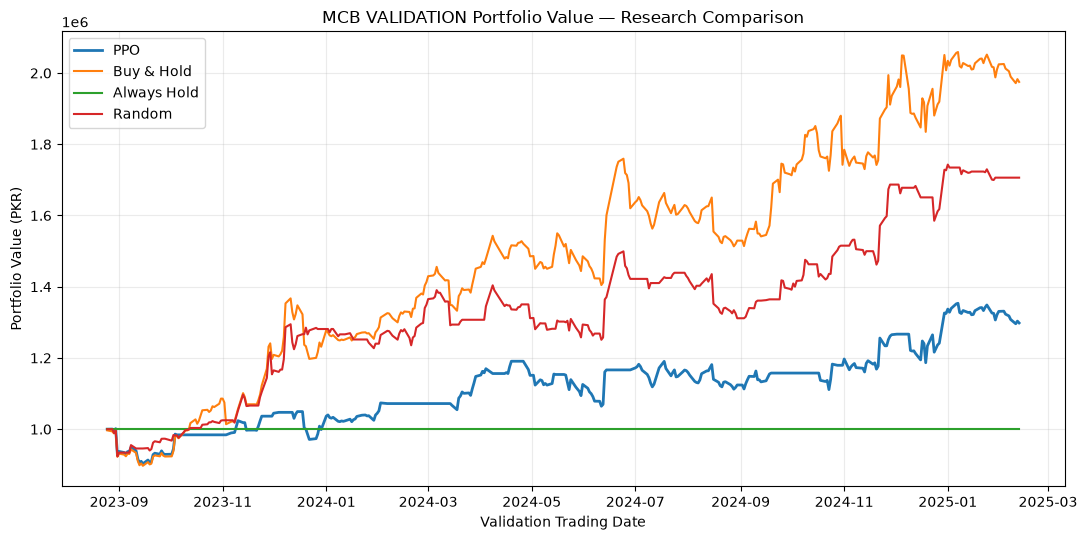

In [12]:
plt.figure(figsize=(11, 5.5))
for label, result in strategy_results.items():
    history = result.history
    plt.plot(pd.to_datetime(history['execution_date']), history['portfolio_value'], label=label, linewidth=2 if label == 'PPO' else 1.5)
plt.title(f'{SYMBOL} VALIDATION Portfolio Value — Research Comparison')
plt.xlabel('Validation Trading Date')
plt.ylabel('Portfolio Value (PKR)')
plt.grid(alpha=0.25)
plt.legend()
plt.tight_layout()
plt.show()

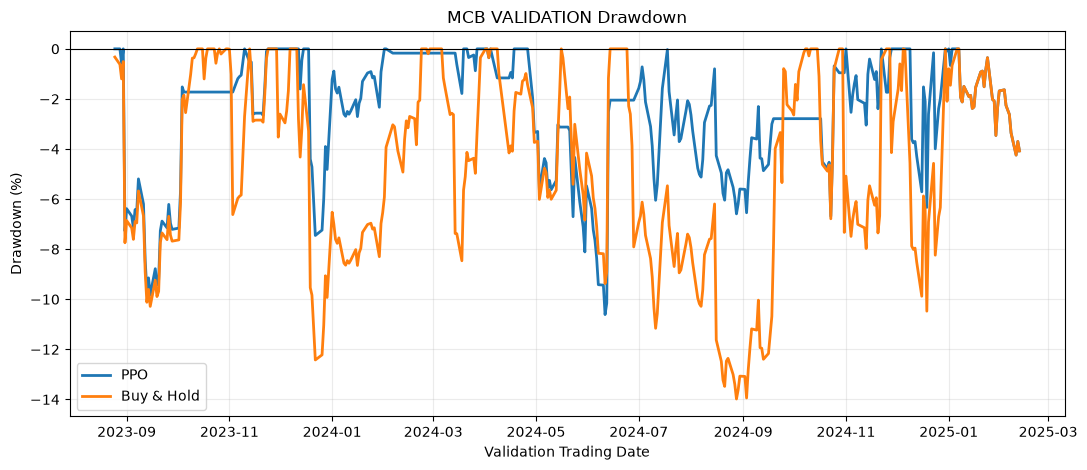

In [13]:
plt.figure(figsize=(11, 4.8))
for label in ('PPO', 'Buy & Hold'):
    history = strategy_results[label].history
    plt.plot(pd.to_datetime(history['execution_date']), -100.0 * history['drawdown'], label=label, linewidth=2)
plt.axhline(0.0, color='black', linewidth=0.8)
plt.title(f'{SYMBOL} VALIDATION Drawdown')
plt.xlabel('Validation Trading Date')
plt.ylabel('Drawdown (%)')
plt.grid(alpha=0.25)
plt.legend()
plt.tight_layout()
plt.show()

## PPO action analysis

Action frequency describes behavior, not performance. Executed trades are measured from actual non-zero share transactions, rather than treating every Buy or Sell decision as a filled trade.

,PPO VALIDATION Actions
Hold Count,12.000000
Buy Count,235.000000
Sell Count,117.000000
Executed Trades,37.000000
Transaction Costs,62929.706518
Percent Time Invested,65.934066
Completed Sells,18.000000
Profitable Completed Sells,14.000000


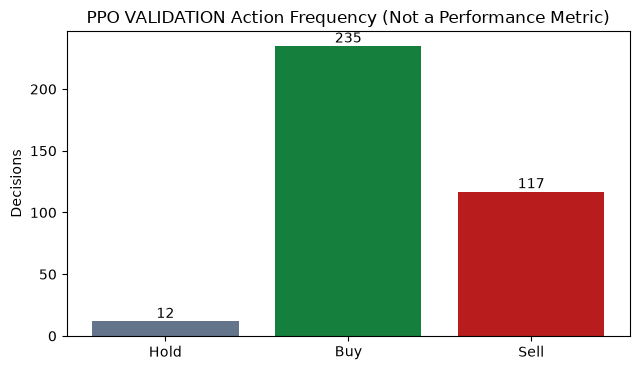

In [14]:
ppo_history = comparison.ppo.history
action_counts = ppo_history['action_name'].value_counts().reindex(['Hold', 'Buy', 'Sell'], fill_value=0)
ppo_metrics = comparison.ppo.metrics
action_summary = pd.Series({
    'Hold Count': int(action_counts['Hold']),
    'Buy Count': int(action_counts['Buy']),
    'Sell Count': int(action_counts['Sell']),
    'Executed Trades': int(ppo_metrics['number_of_trades']),
    'Transaction Costs': float(ppo_metrics['total_transaction_costs']),
    'Percent Time Invested': float(ppo_metrics['exposure_percentage']),
    'Completed Sells': int(ppo_metrics['completed_trades']),
    'Profitable Completed Sells': int(ppo_metrics['profitable_completed_trades']),
}, name='PPO VALIDATION Actions')
display(action_summary.to_frame())

plt.figure(figsize=(6.5, 3.8))
bars = plt.bar(action_counts.index, action_counts.values, color=['#64748b', '#15803d', '#b91c1c'])
plt.title('PPO VALIDATION Action Frequency (Not a Performance Metric)')
plt.ylabel('Decisions')
plt.bar_label(bars)
plt.tight_layout()
plt.show()

## Candidate decision

`validation_pass` means only that the predeclared validation criteria were met; it does **not** make a production model. `validation_fail` does not mean the pipeline is broken—a technically valid model may simply be economically inferior to Buy & Hold.

In [15]:
decision = comparison.candidate_decision
candidate_summary = pd.Series({
    'Validation Status': decision.status,
    'Passed': decision.passed,
    'Criteria Version': decision.criteria_version,
    'PPO vs Buy & Hold Return Difference': comparison.ppo_return_difference_vs_buy_and_hold,
    'PPO vs Buy & Hold Sharpe Difference': comparison.ppo_sharpe_difference_vs_buy_and_hold,
    'PPO Maximum Drawdown': comparison.ppo.metrics['maximum_drawdown'],
    'Buy & Hold Maximum Drawdown': comparison.buy_and_hold.metrics['maximum_drawdown'],
    'PPO vs Buy & Hold Drawdown Difference': comparison.ppo_max_drawdown_difference_vs_buy_and_hold,
}, name='Candidate Decision')
display(candidate_summary.to_frame())
display(pd.Series(decision.thresholds, name='Configured Threshold').to_frame())
display(Markdown('**Reasons:**\n' + '\n'.join(f'- {reason}' for reason in decision.reasons)))
if comparison.warnings:
    display(Markdown('**Evaluation warnings:**\n' + '\n'.join(f'- {warning}' for warning in comparison.warnings)))
else:
    print('Evaluation warnings: None')

,Candidate Decision
Validation Status,validation_fail
Passed,False
Criteria Version,ppo_validation_criteria_v1
PPO vs Buy & Hold Return Difference,-0.676743
PPO vs Buy & Hold Sharpe Difference,-0.750491
PPO Maximum Drawdown,0.106122
Buy & Hold Maximum Drawdown,0.139824
PPO vs Buy & Hold Drawdown Difference,-0.033701


,Configured Threshold
criteria_version,ppo_validation_criteria_v1
minimum_validation_observations,126
minimum_return_advantage_vs_buy_and_hold,0.0
minimum_ppo_sharpe,0.0
minimum_sharpe_advantage_vs_buy_and_hold,0.0
minimum_ppo_sortino,0.0
maximum_ppo_drawdown,0.3
maximum_drawdown_disadvantage_vs_buy_and_hold,0.02


**Reasons:**
- PPO return did not meet the Buy-and-Hold advantage threshold.
- PPO Sharpe ratio did not meet the benchmark advantage.

**Evaluation warnings:**
- Always Hold: zero_return_volatility
- Always Hold: zero_downside_deviation

## Research interpretation

TRAIN and VALIDATION serve different methodological purposes. PPO updates its policy only from TRAIN. VALIDATION then estimates how that fixed policy behaves on later unseen observations and supports candidate selection without contaminating the final TEST set. TEST remains sealed until a future, explicitly authorized final evaluation.

Buy & Hold is a critical benchmark because an active policy must justify its complexity, turnover, and transaction costs relative to passive exposure. A positive PPO return is therefore insufficient if Buy & Hold earns more, achieves better risk-adjusted performance, or incurs a preferable drawdown profile. Always Hold establishes the cash baseline. Fixed-seed Random is a mechanical reference; it may occasionally outperform in one market regime through chance and should never be treated as learned skill.

One symbol, one seed, and one fixed hyperparameter configuration cannot establish generalization. A future pilot should repeat the predeclared workflow across multiple representative symbols and seeds, report dispersion and failure rates, and preserve TEST for one final locked evaluation.

## Temporary persistence round-trip

The notebook demonstrates the production bundle, manifest, registry, and exact-load mechanics only inside an operating-system temporary directory outside the project. The bundle is always an `experiment` marked `not_eligible`, even when validation passes, and is deleted before the cell completes.

In [16]:
from reinforcement_learning.model_management.persistence import (
    load_persisted_ppo, persist_developer_smoke_bundle, verify_artifact_bundle,
)

if decision.status not in {'validation_pass', 'validation_fail'}:
    raise RuntimeError(f'Honest validation status {decision.status!r} is not persistable; no decision will be rewritten')

temporary_root_path = None
with tempfile.TemporaryDirectory(prefix='virtual_trader_notebook05_') as temporary_name:
    temporary_root = Path(temporary_name)
    temporary_root_path = temporary_root
    temporary_registry = temporary_root / 'model_registry.csv'
    temporary_models = temporary_root / 'saved_models'
    persisted = persist_developer_smoke_bundle(
        training_result, comparison, symbol=SYMBOL,
        registry_path=temporary_registry, saved_models_dir=temporary_models,
        splits_dir=PROCESSED_SPLITS_DIR,
        notes='Notebook 05 temporary research experiment; deleted after integrity verification.',
    )
    verification = verify_artifact_bundle(persisted.bundle_path, load_model=True)
    assert verification.manifest_sha256 == persisted.manifest_sha256
    assert verification.metadata['test_evaluation_performed'] is False
    assert verification.metadata['data_availability']['partitions']['test']['evaluation_status'] == 'sealed_not_evaluated'
    assert verification.validation_metrics['evaluation_partition'] == 'validation'
    assert verification.baseline_metrics['evaluation_partition'] == 'validation'
    reloaded = load_persisted_ppo(
        model_id=persisted.model_id, registry_path=temporary_registry,
        saved_models_dir=temporary_models,
    )
    prediction_environment = SingleSymbolTradingEnv(validation_partition.data, environment_config)
    try:
        prediction_observation, _ = prediction_environment.reset(seed=SEED)
        reloaded_action, _ = reloaded.model.predict(prediction_observation, deterministic=True)
    finally:
        prediction_environment.close()
    reloaded_action = int(np.asarray(reloaded_action).item())
    assert reloaded_action in {0, 1, 2}
    temporary_bundle_files = sorted(path.name for path in persisted.bundle_path.iterdir())
    persistence_details = {
        'Model ID': persisted.model_id, 'Model Version': persisted.model_version,
        'Model Status': persisted.model_status, 'Validation Status': persisted.validation_status,
        'Promotion Status': persisted.promotion_status,
        'Manifest SHA-256': persisted.manifest_sha256,
        'Manifest / Hash Verification': True, 'Reload Success': True,
        'Deterministic Reloaded Action': reloaded_action,
        'Temporary Bundle Files': ', '.join(temporary_bundle_files),
    }

temporary_cleanup_success = temporary_root_path is not None and not temporary_root_path.exists()
assert temporary_cleanup_success
persistence_details['Temporary Cleanup Success'] = temporary_cleanup_success
display(pd.Series(persistence_details, name='Temporary Persistence Demonstration').to_frame())

,Temporary Persistence Demonstration
Model ID,ppo-symbol-MCB-v0001
Model Version,1
Model Status,experiment
Validation Status,validation_fail
Promotion Status,not_eligible
Manifest SHA-256,434bdc5555c920b5a9ed11e054a5bd75563ead3a51c927...
Manifest / Hash Verification,True
Reload Success,True
Deterministic Reloaded Action,2
Temporary Bundle Files,"artifact_manifest.json, baseline_comparison_me..."


## Final TEST sealing and production-integrity proof

The final checks restore notebook-local guards, verify that neither TEST file was read, reject TEST-like metric payloads, and compare production registry/model snapshots byte-for-byte.

In [17]:
pd.read_csv = original_pandas_read_csv
trainer_module.load_rl_partition = original_trainer_loader
evaluator_module.load_rl_partition = original_evaluator_loader

loaded_partitions = tuple(item['partition'] for item in partition_access_log)
serialized_validation = json.dumps(comparison.to_dict(include_history=False)).lower()
forbidden_test_metric_keys = ('test_metrics', 'test_performance', 'test_result', 'test_returns')
test_untouched = (
    'test' not in loaded_partitions
    and not sealed_test_read_attempts
    and not any(key in serialized_validation for key in forbidden_test_metric_keys)
)
production_registry_unchanged = (MODEL_REGISTRY_PATH.read_bytes() if MODEL_REGISTRY_PATH.is_file() else None) == production_registry_before
production_saved_models_unchanged = file_tree_snapshot(SAVED_MODELS_DIR) == production_saved_models_before
production_models_data_unchanged = file_tree_snapshot(MODELS_DATA_DIR) == production_models_data_before

assert test_untouched
assert production_registry_unchanged
assert production_saved_models_unchanged
assert production_models_data_unchanged
assert temporary_cleanup_success

sealing_report = pd.Series({
    'Canonical Partitions Loaded': loaded_partitions,
    'TEST CSV Read Attempts': len(sealed_test_read_attempts),
    'TEST Metrics Present': False,
    'TEST Evaluation Performed': False,
    'Production Registry Unchanged': production_registry_unchanged,
    'Production Saved Models Unchanged': production_saved_models_unchanged,
    'Production Models Data Unchanged': production_models_data_unchanged,
    'Production Model Promoted': False,
}, name='Integrity Result')
display(sealing_report.to_frame())
display(Markdown('## FINAL TEST SET: UNTOUCHED'))

,Integrity Result
Canonical Partitions Loaded,"(train, validation, train, validation)"
TEST CSV Read Attempts,0
TEST Metrics Present,False
TEST Evaluation Performed,False
Production Registry Unchanged,True
Production Saved Models Unchanged,True
Production Models Data Unchanged,True
Production Model Promoted,False


## FINAL TEST SET: UNTOUCHED

In [18]:
final_summary = pd.Series({
    'Selected Symbol': SYMBOL,
    'TRAIN Rows / Dates': f"{training_result.training_rows:,} | {training_result.training_start} to {training_result.training_end}",
    'VALIDATION Rows / Dates': f"{comparison.validation_rows:,} | {comparison.validation_start} to {comparison.validation_end}",
    'Requested / Actual Timesteps': f"{training_result.requested_timesteps:,} / {training_result.actual_timesteps:,}",
    'Seed': SEED,
    'Device': f"{training_result.requested_device} → {training_result.resolved_device} ({training_result.device})",
    'PPO Validation Result': comparison.status,
    'PPO Total Return': comparison.ppo.metrics['total_return'],
    'Buy & Hold Total Return': comparison.buy_and_hold.metrics['total_return'],
    'PPO Sharpe': comparison.ppo.metrics['sharpe_ratio'],
    'Buy & Hold Sharpe': comparison.buy_and_hold.metrics['sharpe_ratio'],
    'PPO Maximum Drawdown': comparison.ppo.metrics['maximum_drawdown'],
    'Buy & Hold Maximum Drawdown': comparison.buy_and_hold.metrics['maximum_drawdown'],
    'Candidate Decision': decision.status,
    'TEST Untouched': test_untouched,
    'Production Registry Untouched': production_registry_unchanged,
    'Production Model Promoted': False,
}, name='Notebook 05 Final Summary')
display(final_summary.to_frame())
display(Markdown('**Research conclusion:** this single run validates the methodology and infrastructure only. It is not evidence of production readiness or general profitability.'))

,Notebook 05 Final Summary
Selected Symbol,MCB
TRAIN Rows / Dates,"1,704 | 2016-10-06 to 2023-08-23"
VALIDATION Rows / Dates,365 | 2023-08-24 to 2025-02-12
Requested / Actual Timesteps,"10,240 / 10,240"
Seed,42
Device,cpu → cpu (cpu)
PPO Validation Result,completed
PPO Total Return,0.298314
Buy & Hold Total Return,0.975058
PPO Sharpe,0.94692


**Research conclusion:** this single run validates the methodology and infrastructure only. It is not evidence of production readiness or general profitability.